In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [4]:
DATASET_PATH = "../data/UrbanSoundSubset"
target_classes = ["dog_bark", "drilling", "siren", "street_music"]

In [5]:
for label in target_classes:
    folder_path = os.path.join(DATASET_PATH, label)
    print(label, "->", os.path.exists(folder_path), "->", folder_path)

dog_bark -> True -> ../data/UrbanSoundSubset\dog_bark
drilling -> True -> ../data/UrbanSoundSubset\drilling
siren -> True -> ../data/UrbanSoundSubset\siren
street_music -> True -> ../data/UrbanSoundSubset\street_music


# Create MFCC feature extraction function

In [ ]:
def extract_mfcc_features(file_path, n_mfcc=13):
    # y is the actual sound as numbers, sr is the sampling rate, duration is the length of the audio to load (in seconds) to make consistent feature extraction.
    y, sr = librosa.load(file_path, sr=None, duration=4)   
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    return mfcc_mean

In [9]:
sample_file = os.path.join(DATASET_PATH, "dog_bark", os.listdir(os.path.join(DATASET_PATH, "dog_bark"))[0])
print("Sample file:", sample_file)

sample_features = extract_mfcc_features(sample_file)
print("Feature shape:", sample_features.shape)
print(sample_features)

Sample file: ../data/UrbanSoundSubset\dog_bark\100032-3-0-0.wav
Feature shape: (13,)
[-2.7591843e+02  1.1949280e+02 -9.8211777e+01 -6.6515137e+01
 -4.2606049e+01  5.0506562e-01 -2.8330938e+01 -5.7468672e+00
  9.9927845e+00  4.7954111e+00  1.5461894e+01 -6.9880106e-02
 -2.8426735e+00]


In [10]:
X = []
y = []

for label in target_classes:
    folder_path = os.path.join(DATASET_PATH, label)
    files = os.listdir(folder_path)

    for file_name in files:
        file_path = os.path.join(folder_path, file_name)
        try:
            features = extract_mfcc_features(file_path)
            X.append(features)
            y.append(label)
        except Exception as e:
            print(f"Error processing {file_path}: {e}")

In [11]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 13)
y shape: (400,)


# Split into train and test data

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 320
Testing samples: 80


# Train Random Forest model

In [14]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Make predictions

In [15]:
y_pred = model.predict(X_test)
print(y_pred[:10])

['siren' 'drilling' 'dog_bark' 'dog_bark' 'siren' 'dog_bark'
 'street_music' 'drilling' 'siren' 'dog_bark']


# Evaluate the model


In [16]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9875

Classification Report:
              precision    recall  f1-score   support

    dog_bark       1.00      1.00      1.00        20
    drilling       0.95      1.00      0.98        20
       siren       1.00      0.95      0.97        20
street_music       1.00      1.00      1.00        20

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



# Confusion matrix

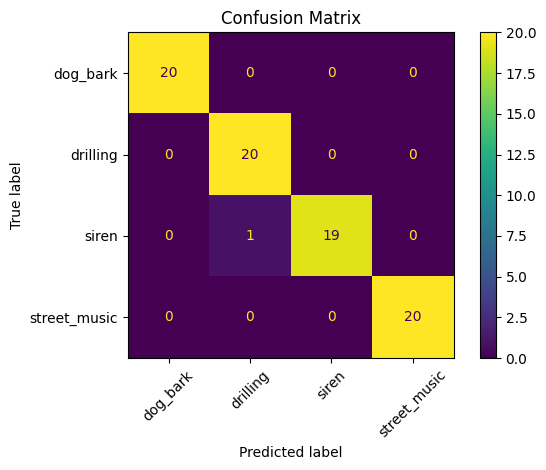

In [17]:
cm = confusion_matrix(y_test, y_pred, labels=target_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_classes)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("../results/confusion_matrix.png")
plt.show()